In [2]:

import pandas as pd
import json

# Load dataset
data = []
with open('../data/raw/dataset_raw.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        try:
            data.append(json.loads(line))
        except:
            pass

df = pd.DataFrame(data)

# Calculate length of content
df['content_length'] = df['content'].apply(lambda x: len(str(x)))

# Get top 20 shortest
shortest_20 = df.nsmallest(20, 'content_length')[['url', 'content_length', 'content']]
shortest_20


,url,content_length,content
5162,https://rumahpusbin.kemendikdasmen.go.id/berit...,28,https://youtu.be/F1BclAqM6iQ
5485,https://rumahpusbin.kemendikdasmen.go.id/berit...,39,elgerakanliterasinasional2023@gmail.com
2155,https://kemdiktisaintek.go.id/news/article/gma...,42,negara maju lainnya dalam kompetisi dunia.
686,https://badanbahasa.kemendikdasmen.go.id/page/...,43,sub/atauhttps://kemendikdasmen.lapor.go.id/
5440,https://bskap.kemendikdasmen.go.id/publikasi/k...,47,daring dan disiarkan di YouTube Kemendikdasmen.
745,https://kemensos.go.id/layanan-publik/sim-psdbs,60,Informasi selengkapnya klikhttps://simppsdbs.k...
5297,https://rumahpusbin.kemendikdasmen.go.id/berit...,72,anak milenial menampilkan secara langsung bebe...
5227,https://rumahpusbin.kemendikdasmen.go.id/berit...,84,"Jakarta, 12 September 2023 di Gedung Dharma Ba..."
5480,https://rumahpusbin.kemendikdasmen.go.id/berit...,108,infromasi lebih lanjut dapat diakses melalui a...
679,https://badanbahasa.kemendikdasmen.go.id/page/...,111,1.Regulasi Keterbukaan Informasi Publik\n\n2.S...


### URL Status Proportions

Status Proportions Table:


,status,count,proportion (%)
0,completed,12085,90.17
1,failed_too_short,890,6.64
2,err_,312,2.33
3,err_Response payload is,93,0.69
4,err_Cannot connect to ho,17,0.13
5,err_database is locked,3,0.02
6,pending,2,0.01
7,failed_not_html,1,0.01


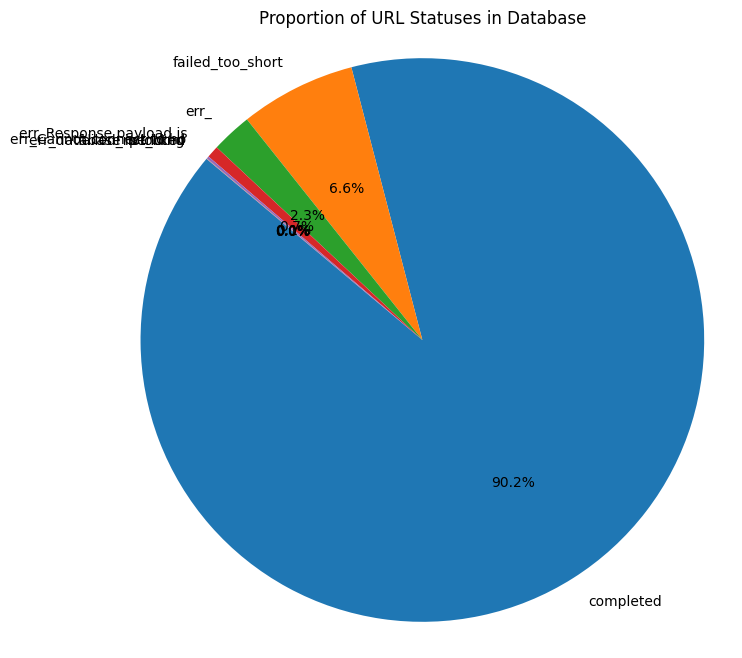

In [3]:

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to database
conn = sqlite3.connect('../data/dedupe.sqlite3')

# Query the status proportions
query = '''
    SELECT status, COUNT(*) as count 
    FROM url_jobs 
    GROUP BY status
'''
df_status = pd.read_sql_query(query, conn)
conn.close()

# Calculate proportions
df_status['proportion (%)'] = (df_status['count'] / df_status['count'].sum() * 100).round(2)
df_status = df_status.sort_values(by='count', ascending=False).reset_index(drop=True)

# Display table
print("Status Proportions Table:")
display(df_status)

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(df_status['count'], labels=df_status['status'], autopct='%1.1f%%', startangle=140)
plt.title('Proportion of URL Statuses in Database')
plt.axis('equal')
plt.show()
